In [4]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL

input_path = "../dataset/quantity_weekly_decor_outlier_fixed.csv"

df = pd.read_csv(input_path)
weeks = df.columns[1:]
dates = pd.date_range(start='2010-12-01', periods=len(weeks), freq='W')
p = 6

def analyze_series_stl(ts, period=6):
    res = {}
    
    ts_diff = ts.diff().dropna()
    adf_diff = adfuller(ts_diff)
    res['ADF_p_value'] = round(adf_diff[1], 4)
    res['Is_Stationarity'] = "Yes" if adf_diff[1] < 0.05 else "No"
    
    stl = STL(ts, period=period, robust=True)
    decomp = stl.fit()
    
    resid = decomp.resid
    trend = decomp.trend
    seasonal = decomp.seasonal
    var_resid = np.var(resid)
    
    var_trend_resid = np.var(trend + resid)
    if var_trend_resid == 0:
        trend_strength = 0
    else:
        trend_strength = max(0, 1 - var_resid / var_trend_resid)
    
    res['Trend_Strength'] = round(trend_strength, 4)
    res['Have_Trend'] = "Yes" if trend_strength > 0.6 else "No"
    
    var_seasonal_resid = np.var(seasonal + resid)
    if var_seasonal_resid == 0:
        seasonal_strength = 0
    else:
        seasonal_strength = max(0, 1 - var_resid / var_seasonal_resid)
        
    res['Seasonal_Strength'] = round(seasonal_strength, 4)
    res['Have_Seasonality'] = "Yes" if seasonal_strength > 0.6 else "No"
    
    return res

final_results = []

for index, row in df.iterrows():
    stock_code = str(row['StockCode'])
    series_data = pd.to_numeric(row[1:], errors='coerce').values.astype(float)
    series_data = np.nan_to_num(series_data, nan=1e-6)
    series_data[series_data <= 0] = 1e-6
    ts = pd.Series(series_data, index=dates)
    
    try:
        stats = analyze_series_stl(ts, period=p)
        stats['StockCode'] = stock_code
        final_results.append(stats)
    except Exception as e:
        print(f"{stock_code}: {e}")

df_results = pd.DataFrame(final_results)
cols = ['StockCode', 'Is_Stationarity', 'ADF_p_value', 'Have_Trend', 'Trend_Strength', 'Have_Seasonality', 'Seasonal_Strength']
df_results = df_results[cols]

print(df_results.to_string(index=False))

StockCode Is_Stationarity  ADF_p_value Have_Trend  Trend_Strength Have_Seasonality  Seasonal_Strength
    22469             Yes       0.0186         No          0.5121               No             0.1086
    22961             Yes       0.0008         No          0.4103               No             0.1059
    21181             Yes       0.0000         No          0.5821               No             0.0000
    21137             Yes       0.0000        Yes          0.8384               No             0.2730
    84978             Yes       0.0004        Yes          0.9407              Yes             0.6526
    21326             Yes       0.0000         No          0.2488               No             0.0000
    22969             Yes       0.0008        Yes          0.6090               No             0.1528
    79321             Yes       0.0002         No          0.5330               No             0.0000
    84945              No       0.0872         No          0.4692               No

In [12]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings("ignore")

def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

forecast_results = []

# Chuỗi dừng và không có xu hướng rõ rệt
target_stocks = df_results[(df_results['Is_Stationarity'] == 'Yes') & 
                           (df_results['Have_Trend'] == 'No')]['StockCode'].tolist()

print(f"Số mã sản phẩm: {len(target_stocks)}/{df.shape[0]}")

for stock in target_stocks:
    series_data = pd.to_numeric(df[df['StockCode'].astype(str) == stock].iloc[0, 1:], errors='coerce').values
    series_data = np.nan_to_num(series_data, nan=1e-6)
    
    # Chia train/test (4 tuần cuối làm test)
    test_size = 4
    train_data = series_data[:-test_size]
    test_data = series_data[-test_size:]
    
    best_aic = float("inf")
    best_order = (0, 0)
    best_model_fit = None

    # Chuỗi dừng và không có xu hướng, ta dùng d=0 (ARMA)
    for p_val in range(3):
        for q_val in range(3):
            try:
                # ARIMA(p, 0, q) tương đương ARMA(p, q)
                model = ARIMA(train_data, order=(p_val, 0, q_val))
                results = model.fit()
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order = (p_val, q_val)
                    best_model_fit = results
            except:
                continue
    
    # Dự báo 4 tuần
    forecast = best_model_fit.forecast(steps=test_size)
    
    # Tính toán độ đo chính xác
    mae = mean_absolute_error(test_data, forecast)
    rmse = np.sqrt(mean_squared_error(test_data, forecast))
    mape = mean_absolute_percentage_error(test_data, forecast)
    
    forecast_results.append({
        'StockCode': stock,
        'Best_Order_pq': best_order,
        'MAE': round(mae, 4), # Trung bình khoảng cách tuyệt đối giữa giá trị dự báo và thực tế
        'RMSE': round(rmse, 4), # Tương tự MAE nhưng phạt nặng sai số lớn
        'MAPE (%)': round(mape, 2), # Sai số chiếm bao nhiêu phần trăm so với giá trị thực tế
        # 'Forecast_2W': list(np.round(forecast[:2], 2)),
        # 'Forecast_4W': list(np.round(forecast, 2)),
        # 'Actual_4W': list(test_data)
    })

df_forecast_compare = pd.DataFrame(forecast_results)
print("\nKết quả:")
print(df_forecast_compare[['StockCode', 'Best_Order_pq', 'MAE', 'RMSE', 'MAPE (%)']].head(50))

Số mã sản phẩm: 17/41

Kết quả:
   StockCode Best_Order_pq     MAE    RMSE  MAPE (%)
0      22469        (2, 2)  0.3500  0.4190      6.07
1      22961        (2, 2)  0.2445  0.2713      4.34
2      21181        (2, 2)  1.2177  1.2499     27.66
3      21326        (2, 2)  0.1666  0.1748      3.07
4      79321        (2, 2)  0.3657  0.3924      7.22
5      22470        (2, 2)  0.4541  0.5526      8.80
6      21166        (1, 2)  0.7652  0.7984     15.07
7      22457        (2, 2)  0.1970  0.2088      3.87
8      23307        (2, 2)  0.5275  0.7546     12.27
9      82583        (2, 0)  0.0666  0.0710      1.62
10     82600        (2, 0)  0.4449  0.4891      9.87
11     71477        (1, 2)  0.1147  0.1532      1.90
12     22147        (2, 1)  0.7642  0.8258     24.92
13     82580        (2, 2)  0.0920  0.1100      1.60
14     22294        (2, 2)  0.1460  0.1594      3.56
15     22722        (2, 2)  0.4085  0.4178     10.01
16     84949        (2, 2)  0.0603  0.0719      1.27


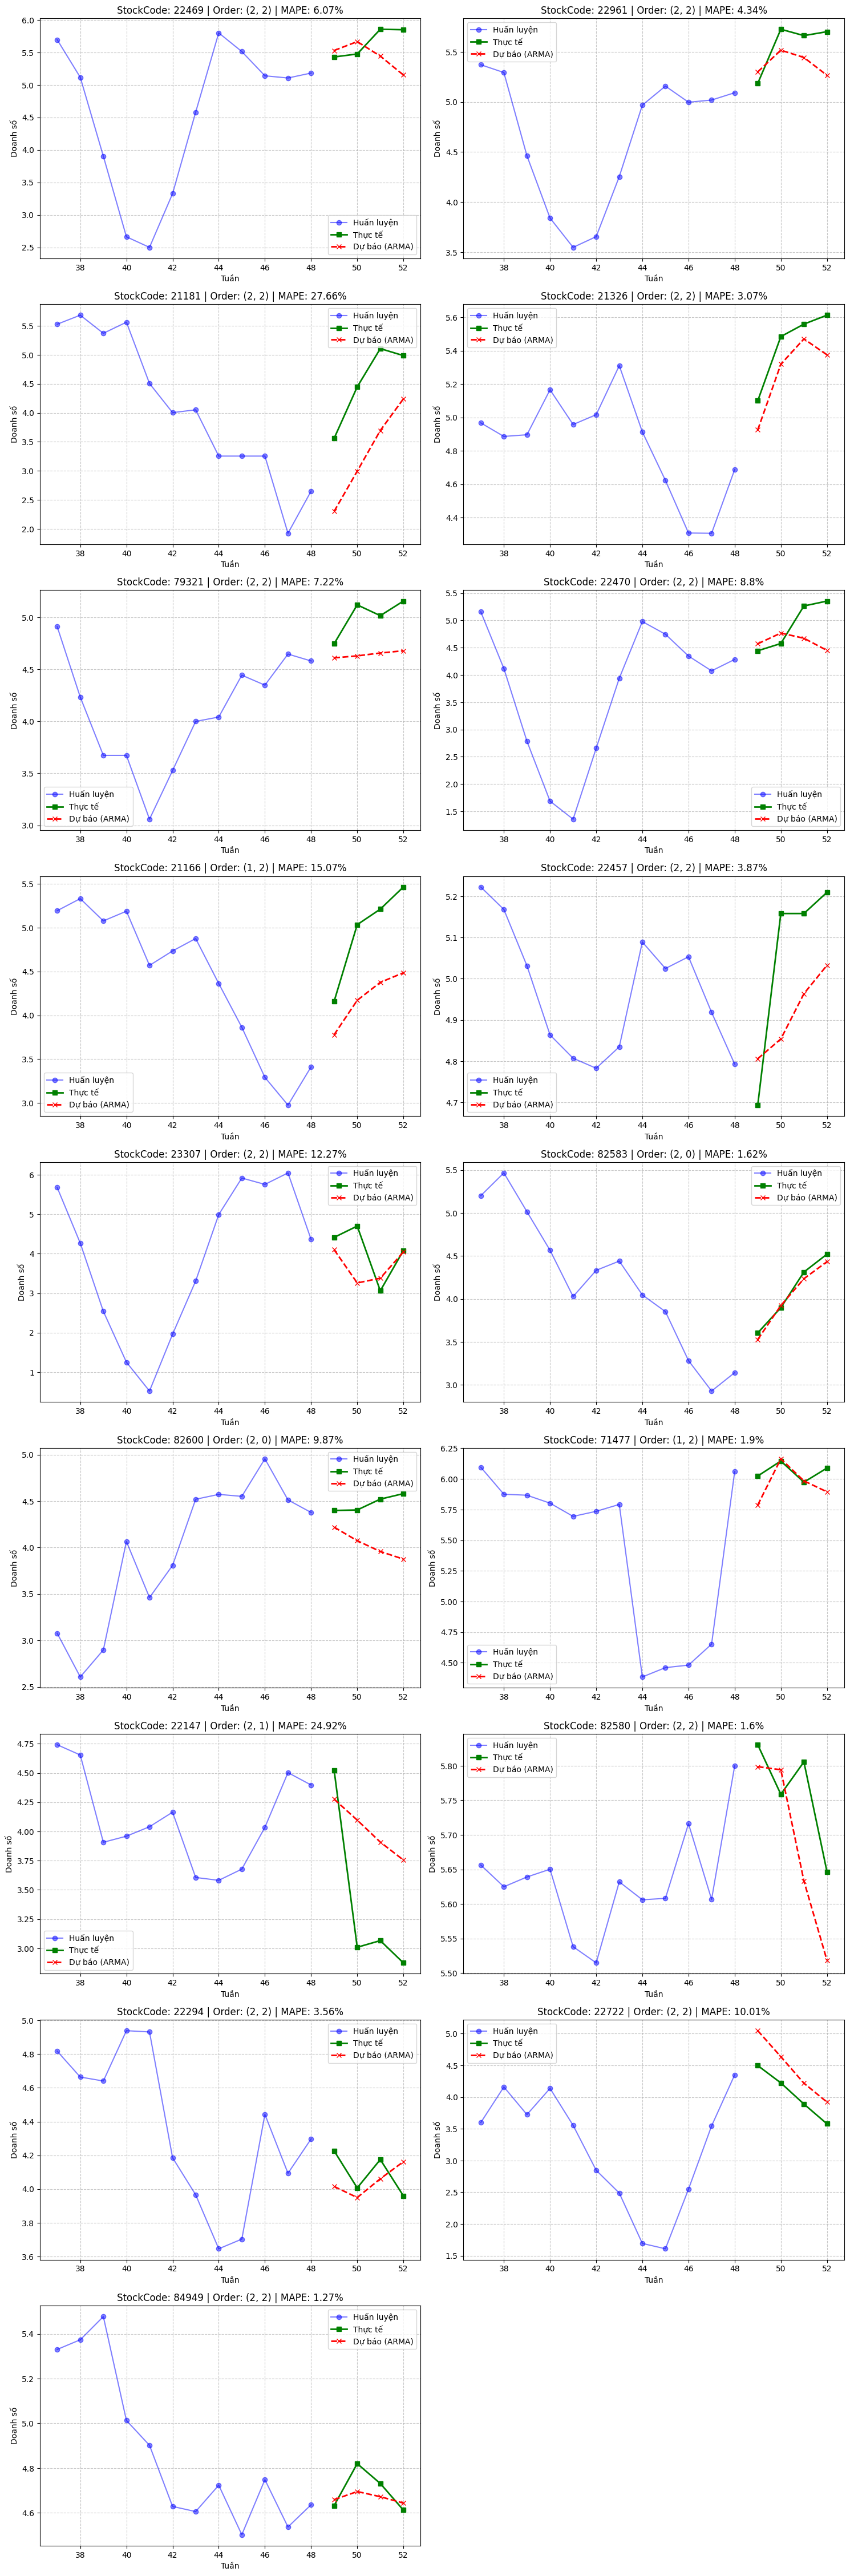

In [18]:
import matplotlib.pyplot as plt

def plot_forecast_results(df, df_results_compare, num_stocks=6):

    stocks_to_plot = df_results_compare['StockCode'].head(num_stocks).tolist()
    
    rows = (num_stocks + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(15, 5 * rows))
    axes = axes.flatten()

    for i, stock in enumerate(stocks_to_plot):
        # Dữ liệu gốc
        series_data = pd.to_numeric(df[df['StockCode'].astype(str) == stock].iloc[0, 1:], errors='coerce').values
        series_data = np.nan_to_num(series_data, nan=1e-6)
        
        test_size = 4
        train_data = series_data[:-test_size]
        test_data = series_data[-test_size:]
        
        # Lấy thông tin model đã tính từ df_forecast_compare
        row_stats = df_results_compare[df_results_compare['StockCode'] == stock].iloc[0]
        order = row_stats['Best_Order_pq']
        
        # Fit lại model để lấy giá trị dự báo vì forecast_results chưa lưu chuỗi forecast cụ thể
        model = ARIMA(train_data, order=(order[0], 0, order[1]))
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=test_size)
        
        ax = axes[i]
        
        # Dữ liệu huấn luyện (12 tuần gần nhất)
        lookback = 12 
        train_idx = np.arange(len(train_data) - lookback, len(train_data))
        ax.plot(train_idx, train_data[-lookback:], label='Huấn luyện', color='blue', marker='o', alpha=0.5)
        
        # Thực tế
        test_idx = np.arange(len(train_data), len(train_data) + test_size)
        ax.plot(test_idx, test_data, label='Thực tế', color='green', marker='s', linewidth=2)
        
        # Dự báo
        ax.plot(test_idx, forecast, label='Dự báo (ARMA)', color='red', linestyle='--', marker='x', linewidth=2)
        
        ax.set_title(f"StockCode: {stock} | Order: {order} | MAPE: {row_stats['MAPE (%)']}%")
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_xlabel("Tuần")
        ax.set_ylabel("Doanh số")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_forecast_results(df, df_forecast_compare, num_stocks=50)